# Skull Fracture and Midline Shift

Analyze whether skull fracture is associated with midline shift.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr
from scipy.stats.contingency import odds_ratio

In [2]:
METADATA_PATH = Path("../data/train/annotated.csv")

SERIES_ID = "series_id"
FRACTURE_COLUMN = "fracture_prob"
MLS_COLUMN = "MLS_mm"

MLS_THRESHOLD_MM = 3.0

## 2. Load Data

Load metadata and keep the columns needed for this analysis.

In [3]:
df = pd.read_csv(METADATA_PATH)

df = df[[SERIES_ID, FRACTURE_COLUMN, MLS_COLUMN]].copy()
df[MLS_COLUMN] = pd.to_numeric(df[MLS_COLUMN], errors="coerce")

print(f"Slices: {len(df):,}")
df.head()

Slices: 4,959


,series_id,fracture_prob,MLS_mm
0,2265,0.0,0.100000
1,2265,0.0,0.100000
2,2265,0.0,0.100000
3,2265,0.0,0.100000
4,2265,0.0,1.776818


## 3. Series-Level Data

Use one row per CT series to avoid counting slices from the same scan as independent samples.

In [4]:
series_df = (
    df.groupby(SERIES_ID, as_index=False)
    .agg(
        fracture=(FRACTURE_COLUMN, "any"),
        mls_mm=(MLS_COLUMN, "max"),
    )
    .dropna()
)

series_df["has_mls"] = series_df["mls_mm"] >= MLS_THRESHOLD_MM

print(f"Series: {len(series_df):,}")
series_df.head()

Series: 188


,series_id,fracture,mls_mm,has_mls
0,447,False,17.149502,True
1,465,False,12.194207,True
2,515,False,2.845519,False
3,519,False,7.173704,True
4,554,False,4.685939,True


## 4. Distribution

Inspect midline-shift values and compare fracture groups.

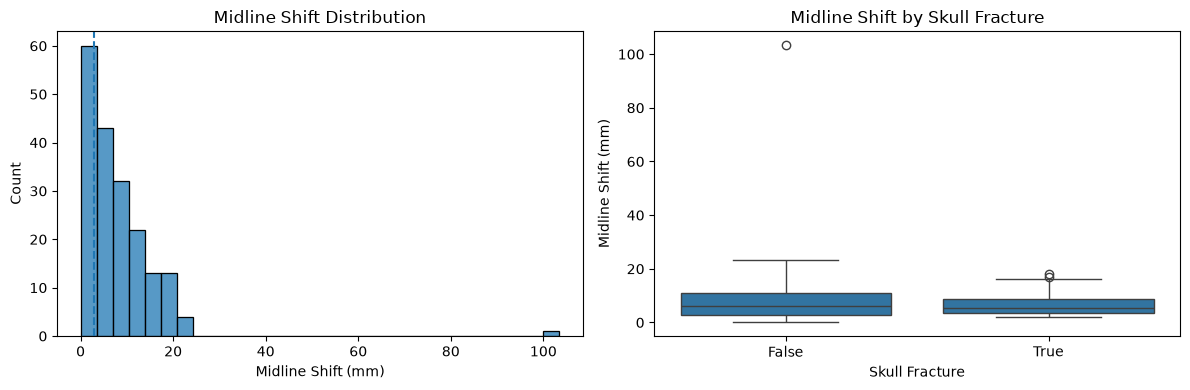

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(series_df, x="mls_mm", bins=30, ax=axes[0])
axes[0].axvline(MLS_THRESHOLD_MM, linestyle="--")
axes[0].set_title("Midline Shift Distribution")
axes[0].set_xlabel("Midline Shift (mm)")

sns.boxplot(series_df, x="fracture", y="mls_mm", ax=axes[1])
axes[1].set_title("Midline Shift by Skull Fracture")
axes[1].set_xlabel("Skull Fracture")
axes[1].set_ylabel("Midline Shift (mm)")

plt.tight_layout()
plt.show()

## 5. Group Summary

Compare the frequency of significant midline shift in fracture and non-fracture series.

In [6]:
summary = series_df.groupby("fracture")["has_mls"].agg(
    total="size", positive="sum", rate="mean"
)

summary["rate"] *= 100
summary.index = ["No Fracture", "Fracture"]

summary.round(2)

,total,positive,rate
No Fracture,160,117,73.12
Fracture,28,23,82.14


## 6. Categorical Association

Test whether fracture status is associated with significant midline shift.

In [7]:
table = pd.crosstab(
    series_df["fracture"],
    series_df["has_mls"],
).reindex(
    index=[False, True],
    columns=[False, True],
    fill_value=0,
)

table.index = ["No Fracture", "Fracture"]
table.columns = ["No MLS", "MLS"]

table

,No MLS,MLS
No Fracture,43,117
Fracture,5,23


In [8]:
chi2, p, _, _ = chi2_contingency(table)

n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print(f"Chi-square = {chi2:.2f}")
print(f"p = {p:.4f}")
print(f"Cramér's V = {cramers_v:.3f}")

Chi-square = 0.60
p = 0.4385
Cramér's V = 0.056


In [9]:
result = odds_ratio(table.to_numpy())
ci = result.confidence_interval()

print(f"Odds ratio = {result.statistic:.3f}")
print(f"95% CI = [{ci.low:.3f}, {ci.high:.3f}]")

Odds ratio = 1.686
95% CI = [0.577, 6.040]


## 7. Continuous Association

Compare the actual midline-shift values between fracture groups.

In [10]:
r, p = pointbiserialr(
    series_df["fracture"].astype(int),
    series_df["mls_mm"],
)

print(f"Point-biserial r = {r:.3f}")
print(f"p = {p:.4f}")

Point-biserial r = -0.041
p = 0.5806


In [11]:
fracture_mls = series_df.loc[series_df["fracture"], "mls_mm"]
no_fracture_mls = series_df.loc[~series_df["fracture"], "mls_mm"]

u, p = mannwhitneyu(
    fracture_mls,
    no_fracture_mls,
    alternative="two-sided",
)

print(f"Mann-Whitney U = {u:.0f}")
print(f"p = {p:.4f}")

Mann-Whitney U = 2235
p = 0.9865


## 8. Interpretation

The results do not show a meaningful association between skull fracture and midline shift in this dataset.

- Significant MLS (≥ 3 mm) was present in **82.8%** of fracture series and **73.2%** of non-fracture series.
- The **chi-square test was not significant** (`p = 0.3886`), with a very small association strength (`Cramér's V = 0.062`).
- The **odds ratio was 1.76**, but the wide 95% confidence interval (`0.61–6.26`) includes 1, so the increase is uncertain.
- The actual MLS values also showed **no meaningful relationship with fracture status** (`r = -0.034`, `p = 0.6382`).
- The **Mann–Whitney U test** found no significant difference in MLS distributions between the two groups (`p = 0.8725`).

Overall, **skull fracture appears to be a weak predictor of midline shift** in this dataset.